# Cosmic Microwave Background 3: Measure the age of the Universe with a standard ruler

## Authors
Nathaniel Starkman ([@nstarman](https://github.com/nstarman))

Adapted from the [*Coding the Cosmos* Cosmic Microwave Background workshop](https://github.com/Coding-the-Cosmos/notebooks/blob/05479e5b98aaa718cf43f931778a78aa61142c49/workshops/cmb.ipynb) by Louis Branch and Yilun Guan.

## Learning Goals
* Convert between angular size, physical size, and distance with `astropy.units` and the `dimensionless_angles` equivalency
* Find local maxima in an image with `scipy.ndimage`, and select them by position with `astropy.coordinates.SkyCoord`
* Reproject cutouts of an image onto a common grid with `reproject`, and stack them
* Compute distances and times in an expanding universe with `astropy.cosmology`

## Keywords
units, coordinates, reproject, image manipulation, cosmology, scipy

## Companion Content
* [astropy.cosmology documentation](https://docs.astropy.org/en/stable/cosmology/)
* [reproject documentation](https://reproject.readthedocs.io)
* [Cosmic Microwave Background 2: Explore an all-sky map of the cosmic microwave background](2_CMB-Sky-Map.ipynb)
* [Make a plot with both redshift and universe age axes](https://learn.astropy.org/tutorials/redshift-plot.html)

## Summary
The hot and cold spots in the cosmic microwave background (CMB) have a characteristic physical size, which makes them a "standard ruler." In this tutorial we will find hot spots in a *Planck* map of the CMB, stack them to measure their typical angular size, and use that size to estimate how far the CMB light has traveled to reach us. We will then use `astropy.cosmology` to turn that distance into the age of the Universe.

*Note: This is tutorial 3 of 3 in a series on the cosmic microwave background.*

## Imports

In [ ]:
%matplotlib inline
import astropy.constants as const
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.utils.data import download_file
from astropy.wcs import WCS
from reproject import reproject_interp
from scipy import ndimage

## Measure the distance to the Moon from its angular size

If we know how big an object really is, and measure how big it looks, we can work out how far away it is. An object of physical size $s$ at distance $d$ covers an angle on the sky of

$$\theta = \frac{s}{d},$$

with $\theta$ in radians, as long as the angle is small. Rearranging, $d = s / \theta$.

We try this on the Moon, which is 3474 km across and covers about 0.52 degrees on the sky:

In [ ]:
moon_diameter = 3474 * u.km
moon_angular_size = 0.52 * u.deg

Dividing a length by an angle gives units of km / deg, not a distance. Radians are a ratio of two lengths, so `astropy.units` can drop them, but only if we allow it with the `dimensionless_angles` equivalency:

In [ ]:
moon_distance = (moon_diameter / moon_angular_size).to(u.km, equivalencies=u.dimensionless_angles())
print(f"Distance to the Moon: {moon_distance:.0f}")

Distance to the Moon: 382780 km


The Moon is about 383,000 km away. Light travels this distance in just over a second:

In [ ]:
moon_light_travel_time = (moon_distance / const.c).to(u.s)
print(f"Light travel time from the Moon: {moon_light_travel_time:.2f}")

Light travel time from the Moon: 1.28 s


We will use the same method to measure the distance to the CMB. The "objects" are its hot spots, which formed from sound waves in the hot, dense early Universe. Before the CMB was released, sound could only travel a certain distance, called the sound horizon. This distance sets the typical size of the hot spots. Measured in today's (expanded) Universe, it is about 150 megaparsecs (Mpc), where 1 Mpc is about 3.26 million light-years.

In [ ]:
sound_horizon = 150 * u.Mpc

## Find hot spots in the CMB map

We download and open the *Planck* CMB map from the [previous tutorial](2_CMB-Sky-Map.ipynb), convert it to microkelvin, and measure its mean and standard deviation, weighting each pixel by its area on the sky as in the previous tutorial:

In [ ]:
# TODO: replace with the Zenodo record for this tutorial series
cmb_url = (
    "https://raw.githubusercontent.com/Coding-the-Cosmos/notebooks/"
    "05479e5b98aaa718cf43f931778a78aa61142c49/data/"
    "COM_CMB_IQU-commander_1024_R2.02_dg16_car.fits"
)
cmb_data, cmb_header = fits.getdata(download_file(cmb_url, cache=True), header=True)
cmb_wcs = WCS(cmb_header).celestial
cmb_map = (cmb_data[0] * u.K).to(u.uK)

row_dec = cmb_wcs.pixel_to_world(np.zeros(cmb_map.shape[0]), np.arange(cmb_map.shape[0])).dec
pixel_weights = np.broadcast_to(np.cos(row_dec).value[:, np.newaxis], cmb_map.shape)

mean_temperature = np.average(cmb_map, weights=pixel_weights)
std_temperature = np.sqrt(np.average((cmb_map - mean_temperature) ** 2, weights=pixel_weights))

A hot spot is a local maximum of the map: a pixel that is hotter than all of the pixels around it. `scipy.ndimage.maximum_filter` replaces each pixel with the largest value within a box around it, so the local maxima are the pixels left unchanged. We use a box 15 pixels across, which spans 2 degrees of declination, so that each hot spot is counted only once, and keep only the clearest hot spots: those more than 2 standard deviations hotter than average. The left and right edges of the map are the same place on the sky (RA = 180 degrees), so we tell `maximum_filter` to wrap around from one to the other with `mode`.

In [ ]:
is_local_maximum = cmb_map.value == ndimage.maximum_filter(cmb_map.value, size=15, mode=("nearest", "wrap"))
is_hot_spot = is_local_maximum & (cmb_map - mean_temperature > 2 * std_temperature)

hot_spot_y, hot_spot_x = np.nonzero(is_hot_spot)
hot_spots = cmb_wcs.pixel_to_world(hot_spot_x, hot_spot_y)
print(f"Number of hot spots: {len(hot_spots)}")

Number of hot spots: 3891


Leftover light from the Milky Way could look like hot spots, so we remove the hot spots within 20 degrees of the Galactic plane. `SkyCoord` transforms the positions to Galactic coordinates, where the latitude `b` is zero on the plane. We also remove the hot spots within 20 degrees of the celestial poles. Every pixel spans the same range of RA, but lines of RA get closer together towards the poles, so the 15-pixel box gets narrower: at a declination of ±70 degrees it is only about 0.7 degrees wide, and the same hot spot can be counted more than once.

In [ ]:
away_from_galactic_plane = np.abs(hot_spots.galactic.b) > 20 * u.deg
away_from_poles = np.abs(hot_spots.dec) < 70 * u.deg
hot_spots = hot_spots[away_from_galactic_plane & away_from_poles]
print(f"Number of hot spots away from the Galactic plane and the poles: {len(hot_spots)}")

Number of hot spots away from the Galactic plane and the poles: 2290


To check our hot spots, we plot a 30-degree cutout of the map and mark the hot spots on it. `scatter_coord` plots `SkyCoord` positions in the right place on a WCSAxes plot:

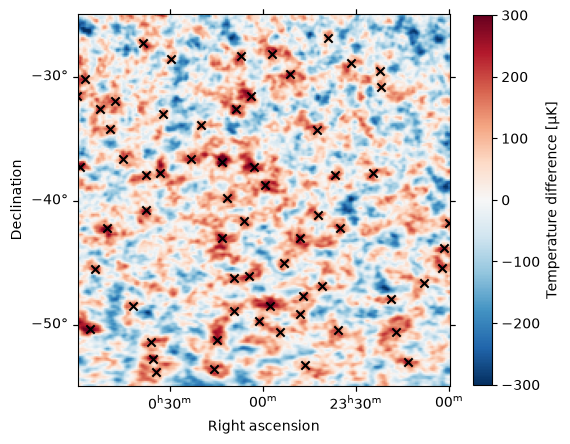

In [ ]:
cutout = Cutout2D(cmb_map.value, position=SkyCoord(ra=0 * u.deg, dec=-40 * u.deg), size=30 * u.deg, wcs=cmb_wcs)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection=cutout.wcs)
image = ax.imshow(cutout.data, origin="lower", cmap="RdBu_r", vmin=-300, vmax=300)
ax.scatter_coord(hot_spots, marker="x", color="k")
ax.set_xlim(-0.5, cutout.shape[1] - 0.5)
ax.set_ylim(-0.5, cutout.shape[0] - 0.5)
ax.coords[0].set_axislabel("Right ascension")
ax.coords[1].set_axislabel("Declination")
fig.colorbar(image, ax=ax, label=f"Temperature difference [{cmb_map.unit:latex}]", shrink=0.8)
plt.show()

Each cross marks the center of one of the hottest (darkest red) spots.

## Stack the hot spots

Any single hot spot is lumpy, because hot spots of different sizes overlap. If we average many of them, the random lumps average away and the typical shape of a hot spot remains. This is called stacking.

To stack the hot spots, every cutout needs to be on the same grid of pixels, centered on its hot spot. The map's projection stretches the sky by different amounts at different declinations, so we cannot use pixel cutouts of the map directly. Instead, for each hot spot we make a new WCS with a gnomonic (`TAN`) projection centered on the hot spot, which is nearly undistorted close to its center, and use `reproject_interp` to resample the map onto it. Each cutout is 2 degrees across, with pixels 2 arcminutes on a side.

In [ ]:
cutout_shape = (61, 61)
cutout_pixel_scale = 2 * u.arcmin


def make_cutout_wcs(center):
    """Make a TAN projection WCS centered on a sky position."""
    cutout_wcs = WCS(naxis=2)
    cutout_wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
    cutout_wcs.wcs.crval = [center.ra.deg, center.dec.deg]
    cutout_wcs.wcs.crpix = [(cutout_shape[1] + 1) / 2, (cutout_shape[0] + 1) / 2]
    cutout_wcs.wcs.cdelt = [-cutout_pixel_scale.to_value(u.deg), cutout_pixel_scale.to_value(u.deg)]
    return cutout_wcs


hot_spot_cutouts = np.array(
    [
        reproject_interp((cmb_map.value, cmb_wcs), make_cutout_wcs(hot_spot), shape_out=cutout_shape)[0]
        for hot_spot in hot_spots
    ]
)
print(hot_spot_cutouts.shape)

(2290, 61, 61)


We now have one 61 by 61 pixel cutout for each hot spot. To see how stacking reduces the noise, we average 1, 10, 100, and all of the cutouts. The hot spots are ordered by their position in the map, so we shuffle them first, so that the first few do not all come from the same part of the sky:

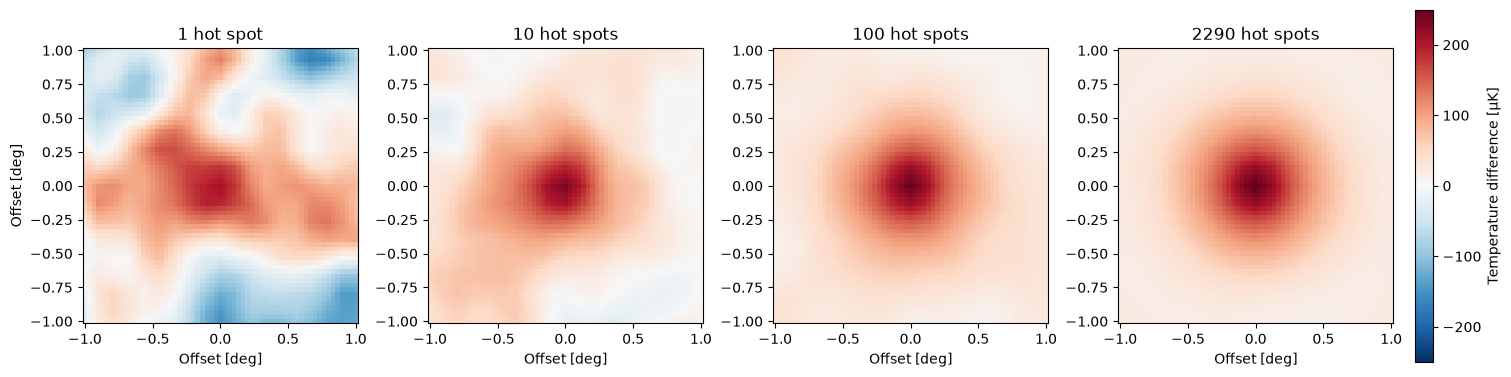

In [ ]:
extent = (np.array([-1, 1, -1, 1]) * cutout_shape[0] / 2 * cutout_pixel_scale).to_value(u.deg)

rng = np.random.default_rng(seed=42)
shuffled_cutouts = rng.permutation(hot_spot_cutouts)

fig, axes = plt.subplots(1, 4, figsize=(15, 4), layout="constrained")
for ax, n_stacked in zip(axes, [1, 10, 100, len(hot_spots)]):
    stacked = np.mean(shuffled_cutouts[:n_stacked], axis=0)
    image = ax.imshow(stacked, origin="lower", cmap="RdBu_r", vmin=-250, vmax=250, extent=extent)
    ax.set_title(f"{n_stacked} hot spot{'s' if n_stacked > 1 else ''}")
    ax.set_xlabel("Offset [deg]")
axes[0].set_ylabel("Offset [deg]")
fig.colorbar(image, ax=axes, label=f"Temperature difference [{cmb_map.unit:latex}]", shrink=0.9, pad=0.01)
plt.show()

As we stack more hot spots, a smooth, round hot spot emerges from the noise.

In [ ]:
stacked_hot_spot = np.mean(hot_spot_cutouts, axis=0) * cmb_map.unit

## Measure the angular size of a hot spot

The stacked hot spot is round, so we describe it by its radial profile: the average temperature at each distance from its center. We compute the distance of every pixel from the center, sort the pixels into rings 0.05 degrees wide, and average the temperature in each ring:

In [ ]:
pixel_y, pixel_x = np.indices(cutout_shape)
center_y, center_x = (np.array(cutout_shape) - 1) / 2
pixel_radius = np.hypot(pixel_x - center_x, pixel_y - center_y) * cutout_pixel_scale

ring_edges = np.arange(0, 1.01, 0.05) * u.deg
ring_centers = (ring_edges[1:] + ring_edges[:-1]) / 2
ring_index = np.digitize(pixel_radius, ring_edges)
profile = u.Quantity([np.mean(stacked_hot_spot[ring_index == i]) for i in range(1, len(ring_edges))])

Following the *Coding the Cosmos* workshop, we define the radius of the hot spot as the distance from its center at which its temperature falls to 30% of its peak. This convention is chosen so that the radius of the stacked hot spot roughly matches the angle that the sound horizon covers on the sky. `np.interp` finds where the profile crosses that value. It expects increasing values, so we pass it the negative of the profile, which increases with radius:

Angular radius of a hot spot: 0.57 deg


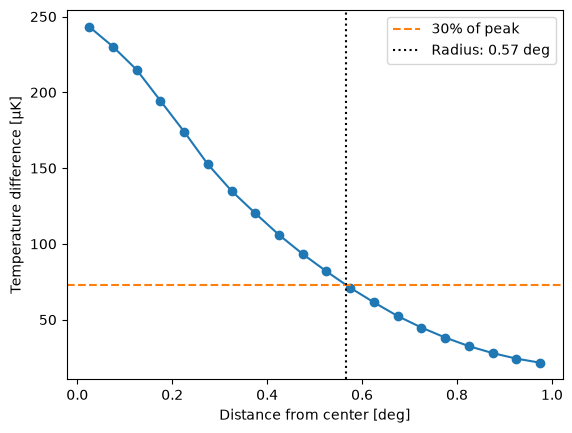

In [ ]:
peak_temperature = profile[0]
hot_spot_radius = np.interp(-0.3 * peak_temperature, -profile, ring_centers)
print(f"Angular radius of a hot spot: {hot_spot_radius:.2f}")

fig, ax = plt.subplots()
ax.plot(ring_centers, profile, marker="o")
ax.axhline(0.3 * peak_temperature.value, color="C1", linestyle="--", label="30% of peak")
ax.axvline(hot_spot_radius.value, color="k", linestyle=":", label=f"Radius: {hot_spot_radius:.2f}")
ax.set_xlabel("Distance from center [deg]")
ax.set_ylabel(f"Temperature difference [{profile.unit:latex}]")
ax.legend()
plt.show()

A typical hot spot has a radius of about 0.6 degrees: on the sky, it is about twice as wide as the full Moon.

<div class="alert alert-info">
This is a rough measurement. The radius we find depends on choices that we made, such as how hot a spot has to be to count as a hot spot, and the 30% threshold. Counting hot spots more than 1σ hotter than average instead of 2σ makes the radius about 20% smaller, and counting only those more than 3σ hotter makes it about 20% larger. The exercise at the end of this tutorial explores this.
</div>

## Convert the angular size into a distance

As with the Moon, the distance is the physical size divided by the angular size:

In [ ]:
cmb_distance = (sound_horizon / hot_spot_radius).to(u.Gpc, equivalencies=u.dimensionless_angles())
print(f"Distance to where the CMB was released: {cmb_distance:.1f}")

Distance to where the CMB was released: 15.2 Gpc


The place where the CMB was released is now about 15 gigaparsecs (Gpc) away, or about 50 billion light-years. If light had traveled that far at a constant speed, its journey would have taken

In [ ]:
naive_travel_time = (cmb_distance / const.c).to(u.Gyr)
print(f"Light travel time: {naive_travel_time:.0f}")

Light travel time: 50 Gyr


about 50 billion years. That is much older than the 13.8 billion year age of the Universe! What went wrong?

## Find the age of the Universe with astropy.cosmology

The Universe expanded while the CMB light traveled to us. The sound horizon of 150 Mpc is its size *today*, after that expansion, so the distance we measured is also the distance *today* to where the CMB was released. Cosmologists call this the comoving distance. While the light was on its way, that place was much closer to us.

`astropy.cosmology` computes distances and times in an expanding universe. We start from `Planck18`, the cosmological model measured mainly from the 2018 release of *Planck*'s CMB data (together with measurements of the distribution of galaxies), and the redshift of about 1100 at which the CMB was released (see the [first tutorial](1_CMB-Blackbody-Temperature.ipynb)). First, we compare our distance with its comoving distance:

In [ ]:
z_release = 1100
planck_distance = Planck18.comoving_distance(z_release).to(u.Gpc)
print(f"Planck18 comoving distance to z = {z_release}: {planck_distance:.1f}")
print(f"Our measurement: {cmb_distance:.1f}")

Planck18 comoving distance to z = 1100: 13.9 Gpc
Our measurement: 15.2 Gpc


Our measurement is about 10% larger. As the note above explains, how close we land depends on the choices we made in measuring the hot spots.

Distances in an expanding universe depend on how fast it expands. The expansion rate today is the Hubble constant, $H_0$. If we keep everything else in the `Planck18` model the same, comoving distances are very nearly inversely proportional to $H_0$. So, assuming that the sound horizon stays 150 Mpc, we can make a cosmology that matches our measurement by scaling $H_0$ with `clone`, which copies a cosmology with some parameters changed:

In [ ]:
measured_cosmology = Planck18.clone(H0=Planck18.H0 * planck_distance / cmb_distance)
print(f"Hubble constant: {measured_cosmology.H0:.1f}")
print(f"Comoving distance to z = {z_release}: {measured_cosmology.comoving_distance(z_release).to(u.Gpc):.1f}")

Hubble constant: 61.9 km / (Mpc s)
Comoving distance to z = 1100: 15.2 Gpc


The comoving distance in this cosmology matches our measurement. The time that the CMB light has really been traveling is called the lookback time:

In [ ]:
lookback_time = measured_cosmology.lookback_time(z_release)
print(f"Light travel time from z = {z_release}: {lookback_time:.1f}")

Light travel time from z = 1100: 15.1 Gyr


The CMB was released very soon after the Big Bang, so the time its light has been traveling is almost exactly the age of the Universe:

In [ ]:
age_today = measured_cosmology.age(0)
age_at_release = measured_cosmology.age(z_release).to(u.kyr)
print(f"Age of the Universe today: {age_today:.1f}")
print(f"Age of the Universe when the CMB was released: {age_at_release:.0f}")

Age of the Universe today: 15.1 Gyr
Age of the Universe when the CMB was released: 387 kyr


Starting from the size of hot spots on a map of the sky, we have estimated the age of the Universe: about 15 billion years. We compare that with the age in the `Planck18` cosmology:

In [ ]:
print(f"Planck18 age of the Universe: {Planck18.age(0):.1f}")

Planck18 age of the Universe: 13.8 Gyr


Our rough measurement is within about 10% of the age that cosmologists find from much more detailed analyses of the CMB: 13.8 billion years.

## Exercise

1. Repeat the measurement of the hot spot radius using hot spots more than 1, 1.5, 2.5, and 3 standard deviations hotter than average. How much does the distance to the CMB change?
2. `Planck18.H0` is 67.7 km/s/Mpc, but some measurements using nearby galaxies find about 73 km/s/Mpc. Make a cosmology with that value using `Planck18.clone(H0=73 * u.km / u.s / u.Mpc)`. How old is the Universe in that cosmology? What angular radius would the hot spots need to have for our method to give that value?